# 04. Synthetic Control

Synthetic control is a quasi-experimental design for settings with one treated aggregate unit, a clear intervention date, and a pool of untreated donor units. Instead of choosing one control unit by hand, we construct a weighted average of donor units that closely matches the treated unit before the intervention.

The method is especially useful when the treated unit is unique: one state, one city, one country, one enterprise customer, one marketplace, one warehouse network, one product line, or one large region. The core question is: can a weighted combination of untreated units reproduce the treated unit's pre-intervention trajectory well enough to be a credible post-intervention counterfactual?


## Learning Goals

By the end of this notebook, you should be able to:

- Explain why synthetic control is useful for one treated aggregate unit.
- Construct donor weights that are nonnegative and sum to one.
- Estimate treatment effects as treated outcome minus synthetic outcome.
- Diagnose pre-treatment fit with path plots, gaps, and RMSPE/RMSE.
- Interpret donor weights and donor-pool composition.
- Run placebo-in-space tests by pretending each donor unit was treated.
- Use leave-one-out sensitivity checks for high-weight donors.
- Recognize when synthetic control is not credible because the treated unit cannot be matched before treatment.
- Translate a synthetic-control analysis into an industry decision readout.


In [1]:
import warnings

import graphviz
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.optimize import minimize

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", "{:.3f}".format)


In [2]:
def make_dag(edges, title=None, node_colors=None, rankdir="LR"):
    graph = graphviz.Digraph(format="svg")
    graph.attr(rankdir=rankdir, bgcolor="white", pad="0.2")
    graph.attr("node", shape="box", style="rounded,filled", color="#334155", fontname="Helvetica")
    graph.attr("edge", color="#475569", arrowsize="0.8")

    node_colors = node_colors or {}
    nodes = sorted({node for edge in edges for node in edge[:2]})
    for node in nodes:
        graph.node(node, fillcolor=node_colors.get(node, "#eef2ff"))

    for edge in edges:
        if len(edge) == 2:
            graph.edge(edge[0], edge[1])
        else:
            graph.edge(edge[0], edge[1], label=edge[2])

    if title:
        graph.attr(label=title, labelloc="t", fontsize="18", fontname="Helvetica-Bold")
    return graph


def rmse(values):
    values = np.asarray(values, dtype=float)
    return float(np.sqrt(np.mean(values**2)))


def summarize_path(path_frame, intervention_month):
    pre = path_frame["month"] < intervention_month
    post = ~pre
    return pd.Series(
        {
            "pre_RMSE": rmse(path_frame.loc[pre, "gap"]),
            "post_RMSE": rmse(path_frame.loc[post, "gap"]),
            "post_to_pre_RMSE_ratio": rmse(path_frame.loc[post, "gap"]) / rmse(path_frame.loc[pre, "gap"]),
            "average_post_gap": path_frame.loc[post, "gap"].mean(),
        }
    )


## 1. Where Synthetic Control Fits

Difference-in-differences needs a comparison group whose untreated trend represents the treated group's untreated trend. Synthetic control builds that comparison group explicitly. It chooses donor weights so the synthetic unit tracks the treated unit before the intervention.

The canonical examples are policy case studies: the Basque Country conflict study (Abadie & Gardeazabal, 2003) and California's tobacco-control program (Abadie, Diamond, & Hainmueller, 2010). The same design appears in industry when a major change affects one unit first:

- A flagship market launches a new pricing policy.
- One fulfillment region receives a routing algorithm.
- One enterprise customer receives a premium support workflow.
- One country gets regulatory approval for a product feature.
- One warehouse network gets a labor-scheduling intervention.

Synthetic control is not magic. Its credibility comes from design transparency: the donor pool, weights, pre-treatment fit, and placebo checks are all visible.


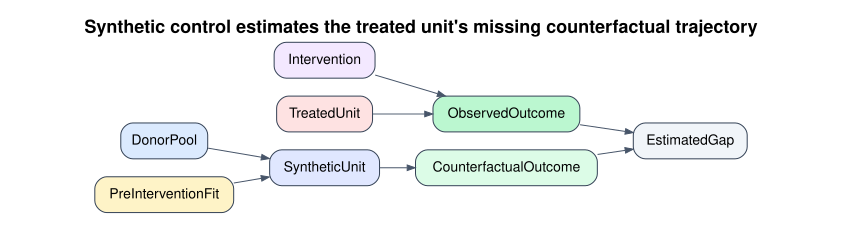

In [3]:
make_dag(
    edges=[
        ("DonorPool", "SyntheticUnit"),
        ("PreInterventionFit", "SyntheticUnit"),
        ("SyntheticUnit", "CounterfactualOutcome"),
        ("TreatedUnit", "ObservedOutcome"),
        ("Intervention", "ObservedOutcome"),
        ("CounterfactualOutcome", "EstimatedGap"),
        ("ObservedOutcome", "EstimatedGap"),
    ],
    title="Synthetic control estimates the treated unit's missing counterfactual trajectory",
    node_colors={
        "DonorPool": "#dbeafe",
        "SyntheticUnit": "#e0e7ff",
        "PreInterventionFit": "#fef3c7",
        "CounterfactualOutcome": "#dcfce7",
        "TreatedUnit": "#fee2e2",
        "ObservedOutcome": "#bbf7d0",
        "Intervention": "#f3e8ff",
        "EstimatedGap": "#f1f5f9",
    },
)


The treated unit has an observed post-intervention path, but its untreated post-intervention path is missing. Synthetic control fills that missing path using a weighted donor combination chosen before looking at post-treatment outcomes.


## 2. The Optimization Problem

Let $Y_{1t}$ be the treated unit outcome and $Y_{jt}$ be donor unit $j$'s outcome. We choose weights $w_j$ to match the treated unit before treatment:

$$
\hat{W} = \arg\min_W \sum_{t < T_0}\left(Y_{1t} - \sum_{j=1}^{J} w_j Y_{jt}\right)^2
$$

subject to:

$$
w_j \ge 0 \quad \text{and} \quad \sum_{j=1}^{J} w_j = 1
$$

The synthetic counterfactual after treatment is:

$$
\hat{Y}_{1t}(0) = \sum_{j=1}^{J} \hat{w}_j Y_{jt}
$$

and the estimated treatment effect is:

$$
\hat{\tau}_t = Y_{1t} - \hat{Y}_{1t}(0)
$$

Abadie, Diamond, and Hainmueller (2011) emphasize that synthetic control makes the comparison transparent: the selected donors, their weights, and the quality of the pre-treatment match are all inspectable.


## 3. Running Example: One Market Launches a Premium Support Policy

Suppose one flagship market launches a premium AI-assisted support policy at month 30. The outcome is monthly net revenue per account. Other markets do not launch the policy during the observation window.

We will simulate 20 donor markets. The treated market's untreated path is close to a convex combination of a few donors, which is exactly the setting where synthetic control should work well.


In [4]:
def simulate_synthetic_control_data(n_donors=20, months=range(48), intervention_month=30, seed=4404):
    rng = np.random.default_rng(seed)
    months = np.array(list(months))

    macro = 0.18 * months + 2.2 * np.sin(months / 4.0) + 1.0 * np.cos(months / 9.0)
    seasonal = np.sin(2 * np.pi * months / 12)

    donor_rows = []
    for donor_id in range(n_donors):
        intercept = rng.normal(80, 7)
        trend = rng.normal(0.35, 0.08)
        macro_loading = rng.normal(1.0, 0.18)
        season_loading = rng.normal(1.8, 0.5)
        curvature = rng.normal(0, 0.002)
        eps_prev = rng.normal(0, 1.0)

        for month in months:
            eps = 0.55 * eps_prev + rng.normal(0, 1.0)
            eps_prev = eps
            outcome = (
                intercept
                + trend * month
                + macro_loading * macro[month]
                + season_loading * seasonal[month]
                + curvature * (month - 24) ** 2
                + eps
            )
            donor_rows.append(
                {
                    "unit": f"Donor {donor_id + 1:02d}",
                    "month": int(month),
                    "outcome": outcome,
                    "treated_unit": 0,
                    "post": int(month >= intervention_month),
                    "true_effect": 0.0,
                    "untreated_outcome": outcome,
                }
            )

    donor_df = pd.DataFrame(donor_rows)
    donor_matrix = donor_df.pivot(index="month", columns="unit", values="outcome").sort_index()

    true_weights = np.zeros(n_donors)
    true_weights[[2, 6, 13, 17]] = [0.36, 0.27, 0.22, 0.15]
    untreated_treated = donor_matrix.to_numpy() @ true_weights

    idiosyncratic = []
    eps_prev = rng.normal(0, 0.4)
    for _ in months:
        eps_prev = 0.50 * eps_prev + rng.normal(0, 0.3)
        idiosyncratic.append(eps_prev)
    untreated_treated = untreated_treated + np.array(idiosyncratic)

    treatment_effect = np.where(months >= intervention_month, 2.0 + 0.55 * (months - intervention_month), 0.0)
    treatment_effect = np.minimum(treatment_effect, 9.0)
    observed_treated = untreated_treated + treatment_effect

    treated_df = pd.DataFrame(
        {
            "unit": "Treated Market",
            "month": months.astype(int),
            "outcome": observed_treated,
            "treated_unit": 1,
            "post": (months >= intervention_month).astype(int),
            "true_effect": treatment_effect,
            "untreated_outcome": untreated_treated,
        }
    )

    frame = pd.concat([donor_df, treated_df], ignore_index=True)
    true_weight_table = pd.DataFrame(
        {
            "unit": [f"Donor {idx + 1:02d}" for idx in range(n_donors)],
            "true_data_generating_weight": true_weights,
        }
    )
    return frame, true_weight_table


intervention_month = 30
df, true_weight_table = simulate_synthetic_control_data(intervention_month=intervention_month)

data_summary = pd.Series(
    {
        "units": df["unit"].nunique(),
        "donor_units": df["unit"].nunique() - 1,
        "months": df["month"].nunique(),
        "intervention_month": intervention_month,
        "post_months": df.loc[df["post"].eq(1), "month"].nunique(),
        "true_average_post_effect": df.loc[df["unit"].eq("Treated Market") & df["post"].eq(1), "true_effect"].mean(),
    }
).to_frame("value")
data_summary


,value
units,21.000
donor_units,20.000
months,48.000
intervention_month,30.000
post_months,18.000
true_average_post_effect,6.328


In real data we would not know the true weights or true effect. We include them only to make the mechanics testable.


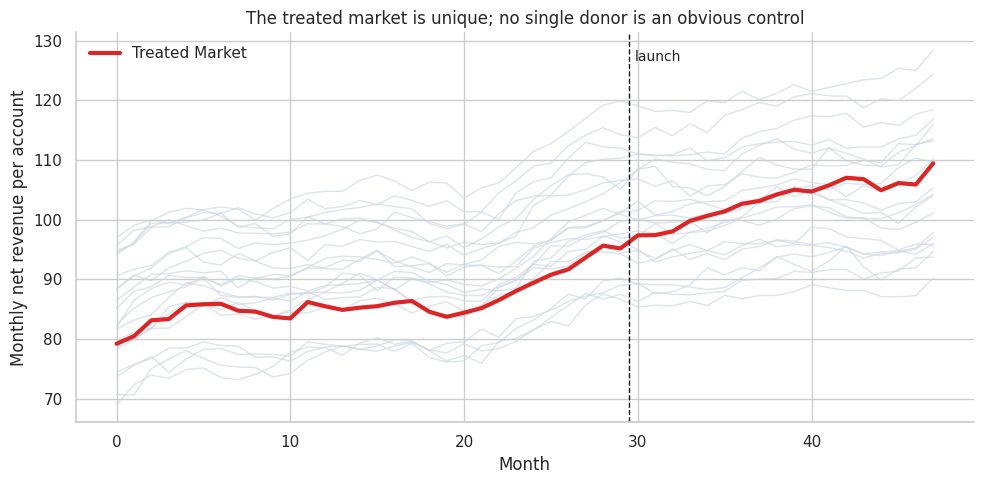

In [5]:
wide = df.pivot(index="month", columns="unit", values="outcome").sort_index()

fig, ax = plt.subplots(figsize=(10, 5.0))
for unit in wide.columns:
    if unit == "Treated Market":
        ax.plot(wide.index, wide[unit], color="#dc2626", linewidth=3, label="Treated Market")
    else:
        ax.plot(wide.index, wide[unit], color="#cbd5e1", linewidth=1, alpha=0.65)
ax.axvline(intervention_month - 0.5, color="#111827", linestyle="--", linewidth=1)
ax.text(intervention_month - 0.2, wide.max().max(), "launch", ha="left", va="top", fontsize=10)
ax.set_title("The treated market is unique; no single donor is an obvious control")
ax.set_xlabel("Month")
ax.set_ylabel("Monthly net revenue per account")
ax.legend(frameon=False)
sns.despine(ax=ax)
plt.tight_layout()


The treated market sits among the donors but does not obviously equal any single donor. Synthetic control asks whether a weighted donor combination can match the treated path before month 30.


## 4. Fit the Synthetic Control

We will fit weights using only months before the intervention. The optimizer knows nothing about post-intervention outcomes.


In [6]:
def fit_synthetic_control(frame, treated_unit, donor_units=None, intervention_month=30, fit_months=None):
    wide = frame.pivot(index="month", columns="unit", values="outcome").sort_index()
    if donor_units is None:
        donor_units = [unit for unit in wide.columns if unit != treated_unit]
    if fit_months is None:
        fit_months = [month for month in wide.index if month < intervention_month]

    X0 = wide.loc[fit_months, donor_units].to_numpy()
    x1 = wide.loc[fit_months, treated_unit].to_numpy()
    n_donors = len(donor_units)
    initial_weights = np.repeat(1 / n_donors, n_donors)

    def objective(weights):
        return np.mean((x1 - X0 @ weights) ** 2)

    constraints = {"type": "eq", "fun": lambda weights: weights.sum() - 1}
    bounds = [(0.0, 1.0)] * n_donors
    result = minimize(
        objective,
        initial_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={"ftol": 1e-12, "maxiter": 2000},
    )

    weights = result.x
    synthetic_path = wide[donor_units].to_numpy() @ weights
    path = pd.DataFrame(
        {
            "month": wide.index,
            "treated": wide[treated_unit].to_numpy(),
            "synthetic": synthetic_path,
        }
    )
    path["gap"] = path["treated"] - path["synthetic"]

    weight_table = pd.DataFrame({"unit": donor_units, "weight": weights}).sort_values("weight", ascending=False)
    return weight_table, path, result


donor_units = [unit for unit in wide.columns if unit != "Treated Market"]
weight_table, synth_path, optimizer_result = fit_synthetic_control(
    df,
    treated_unit="Treated Market",
    donor_units=donor_units,
    intervention_month=intervention_month,
)

pd.Series(
    {
        "optimizer_success": optimizer_result.success,
        "optimizer_objective_pre_MSE": optimizer_result.fun,
        "sum_of_weights": weight_table["weight"].sum(),
        "nonzero_weight_count": (weight_table["weight"] > 0.01).sum(),
    }
).to_frame("value")


,value
optimizer_success,True
optimizer_objective_pre_MSE,0.108
sum_of_weights,1.000
nonzero_weight_count,7


In [7]:
weight_display = (
    weight_table.merge(true_weight_table, on="unit", how="left")
    .assign(weight=lambda x: x["weight"].where(x["weight"].abs() > 1e-6, 0.0))
)
weight_display.head(10)


,unit,weight,true_data_generating_weight
0,Donor 03,0.249,0.360
1,Donor 14,0.222,0.220
2,Donor 07,0.198,0.270
3,Donor 18,0.183,0.150
4,Donor 02,0.083,0.000
5,Donor 10,0.043,0.000
6,Donor 04,0.022,0.000
7,Donor 08,0.000,0.000
8,Donor 11,0.000,0.000
9,Donor 01,0.000,0.000


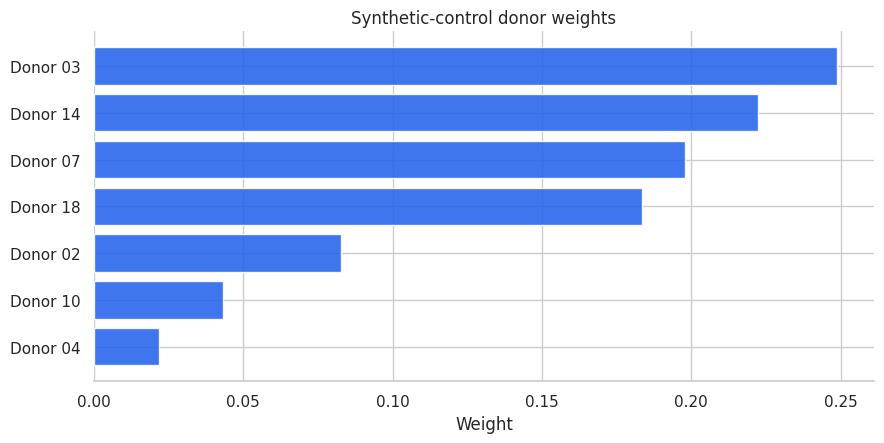

In [8]:
fig, ax = plt.subplots(figsize=(9, 4.6))
plot_weights = weight_display[weight_display["weight"] > 0.005].sort_values("weight")
ax.barh(plot_weights["unit"], plot_weights["weight"], color="#2563eb", alpha=0.88)
ax.set_title("Synthetic-control donor weights")
ax.set_xlabel("Weight")
ax.set_ylabel("")
sns.despine(ax=ax, left=True)
plt.tight_layout()


The weights are sparse: only a few donors contribute meaningfully. This is one reason synthetic control is easy to explain to nontechnical stakeholders. We can say which markets are forming the counterfactual and how much each contributes.


## 5. Path Plot and Gap Plot

The first diagnostic is the path plot: treated outcome versus synthetic outcome. The second is the gap plot: treated minus synthetic. A credible synthetic control should have small pre-treatment gaps.


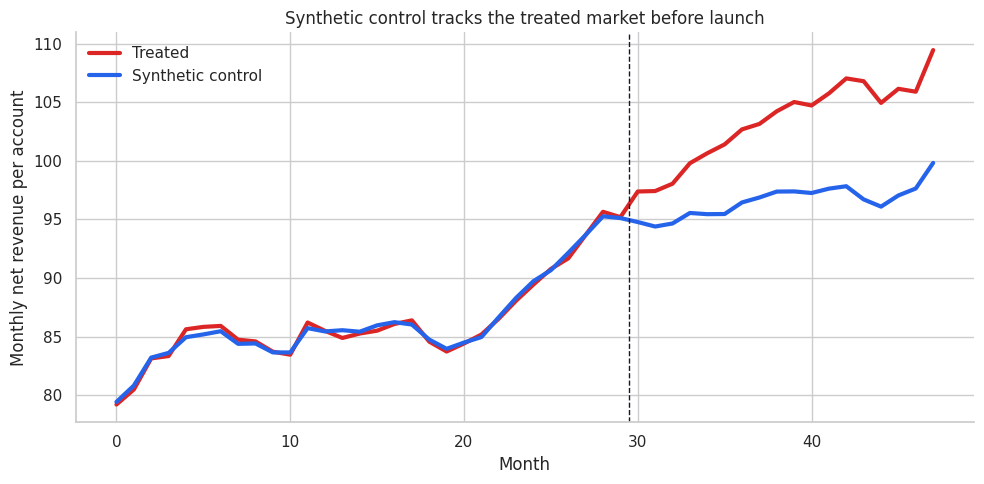

In [9]:
def plot_synthetic_path(path_frame, intervention_month, title):
    fig, ax = plt.subplots(figsize=(10, 5.0))
    ax.plot(path_frame["month"], path_frame["treated"], color="#dc2626", linewidth=3, label="Treated")
    ax.plot(path_frame["month"], path_frame["synthetic"], color="#2563eb", linewidth=3, label="Synthetic control")
    ax.axvline(intervention_month - 0.5, color="#111827", linestyle="--", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("Month")
    ax.set_ylabel("Monthly net revenue per account")
    ax.legend(frameon=False)
    sns.despine(ax=ax)
    plt.tight_layout()
    return fig, ax


def plot_gap(path_frame, intervention_month, title):
    fig, ax = plt.subplots(figsize=(10, 4.6))
    ax.plot(path_frame["month"], path_frame["gap"], color="#7c3aed", linewidth=2.5)
    ax.axhline(0, color="#111827", linestyle="--", linewidth=1)
    ax.axvline(intervention_month - 0.5, color="#111827", linestyle=":", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("Month")
    ax.set_ylabel("Treated minus synthetic")
    sns.despine(ax=ax)
    plt.tight_layout()
    return fig, ax


plot_synthetic_path(synth_path, intervention_month, "Synthetic control tracks the treated market before launch");


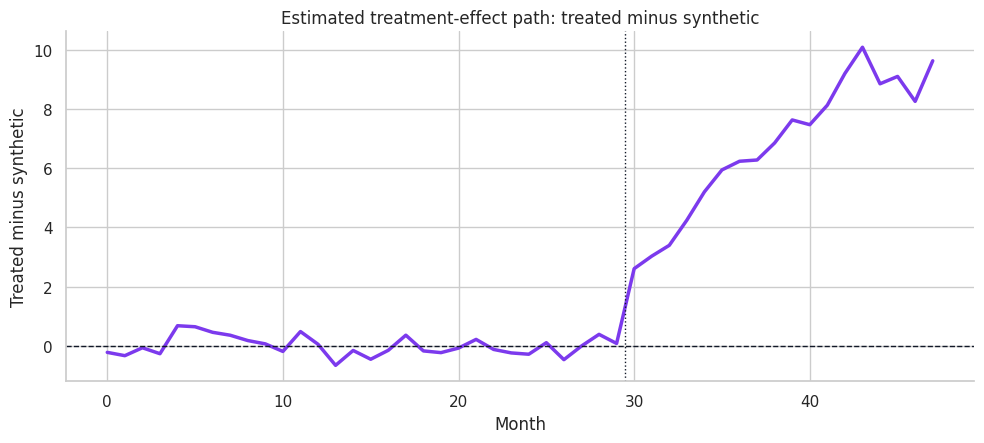

In [10]:
plot_gap(synth_path, intervention_month, "Estimated treatment-effect path: treated minus synthetic");


In [11]:
fit_summary = summarize_path(synth_path, intervention_month).to_frame("synthetic_control")
true_average_post_effect = df.loc[df["unit"].eq("Treated Market") & df["post"].eq(1), "true_effect"].mean()
fit_summary.loc["true_average_post_effect", "synthetic_control"] = true_average_post_effect
fit_summary.loc["bias_in_average_post_gap", "synthetic_control"] = (
    fit_summary.loc["average_post_gap", "synthetic_control"] - true_average_post_effect
)
fit_summary


,synthetic_control
pre_RMSE,0.329
post_RMSE,7.156
post_to_pre_RMSE_ratio,21.748
average_post_gap,6.786
true_average_post_effect,6.328
bias_in_average_post_gap,0.458


The pre-treatment fit is strong: the synthetic unit tracks the treated unit closely before launch. After launch, the treated market rises above the synthetic control. In a real project, the post-launch gap is the estimated effect path.

The single average post gap is useful, but the time path matters too. A premium support policy may take time to affect renewals, upsells, or customer health; the gap plot shows that dynamic story.


## 6. Compare Against Simpler Controls

Synthetic control should beat naive alternatives in pre-treatment fit. We compare it with:

- A simple average of all donor markets.
- The single donor with the best pre-treatment fit.

If synthetic control does not improve pre-treatment fit over these simple baselines, the added complexity may not be worthwhile.


In [12]:
def simple_control_paths(frame, treated_unit, donor_units, intervention_month):
    wide = frame.pivot(index="month", columns="unit", values="outcome").sort_index()
    treated = wide[treated_unit]
    donor_average = wide[donor_units].mean(axis=1)

    pre_months = wide.index < intervention_month
    donor_pre_rmse = {
        donor: rmse(treated.loc[pre_months] - wide.loc[pre_months, donor])
        for donor in donor_units
    }
    best_donor = min(donor_pre_rmse, key=donor_pre_rmse.get)

    output = pd.DataFrame(
        {
            "month": wide.index,
            "treated": treated.to_numpy(),
            "donor_average": donor_average.to_numpy(),
            "best_single_donor": wide[best_donor].to_numpy(),
        }
    )
    output["gap_donor_average"] = output["treated"] - output["donor_average"]
    output["gap_best_single_donor"] = output["treated"] - output["best_single_donor"]
    return output, best_donor


simple_paths, best_donor = simple_control_paths(df, "Treated Market", donor_units, intervention_month)
comparison_metrics = pd.DataFrame(
    {
        "method": ["Synthetic control", "Average donor", f"Best single donor ({best_donor})"],
        "pre_RMSE": [
            rmse(synth_path.loc[synth_path["month"] < intervention_month, "gap"]),
            rmse(simple_paths.loc[simple_paths["month"] < intervention_month, "gap_donor_average"]),
            rmse(simple_paths.loc[simple_paths["month"] < intervention_month, "gap_best_single_donor"]),
        ],
        "average_post_gap": [
            synth_path.loc[synth_path["month"] >= intervention_month, "gap"].mean(),
            simple_paths.loc[simple_paths["month"] >= intervention_month, "gap_donor_average"].mean(),
            simple_paths.loc[simple_paths["month"] >= intervention_month, "gap_best_single_donor"].mean(),
        ],
    }
)
comparison_metrics


,method,pre_RMSE,average_post_gap
0,Synthetic control,0.329,6.786
1,Average donor,5.407,0.556
2,Best single donor (Donor 01),1.170,8.416


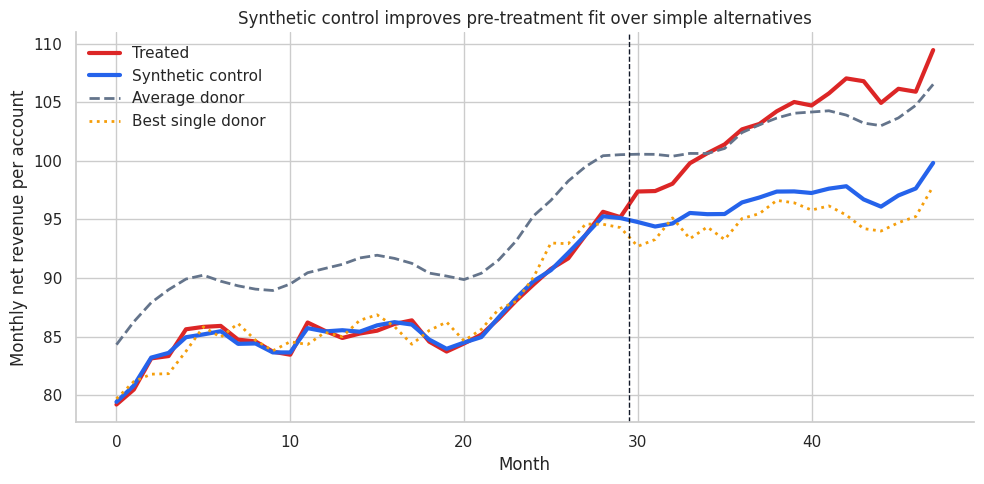

In [13]:
fig, ax = plt.subplots(figsize=(10, 5.0))
ax.plot(synth_path["month"], synth_path["treated"], color="#dc2626", linewidth=3, label="Treated")
ax.plot(synth_path["month"], synth_path["synthetic"], color="#2563eb", linewidth=3, label="Synthetic control")
ax.plot(simple_paths["month"], simple_paths["donor_average"], color="#64748b", linewidth=2, linestyle="--", label="Average donor")
ax.plot(simple_paths["month"], simple_paths["best_single_donor"], color="#f59e0b", linewidth=2, linestyle=":", label="Best single donor")
ax.axvline(intervention_month - 0.5, color="#111827", linestyle="--", linewidth=1)
ax.set_title("Synthetic control improves pre-treatment fit over simple alternatives")
ax.set_xlabel("Month")
ax.set_ylabel("Monthly net revenue per account")
ax.legend(frameon=False)
sns.despine(ax=ax)
plt.tight_layout()


The average donor is too blunt, and the best single donor is still not as close as the weighted combination. Synthetic control earns its keep by improving the pre-treatment match.


## 7. Placebo-in-Space Tests

Classical synthetic-control inference often uses placebo tests. We pretend each donor was treated at the same intervention date, rebuild a synthetic control from the remaining donors, and compare the donor placebo gaps with the treated-unit gap.

If the treated unit's post/pre RMSPE ratio is unusually large relative to placebo ratios, the observed effect is less likely to be ordinary donor-pool noise.

Abadie, Diamond, and Hainmueller (2011) describe these placebo checks as permutation-style inference: the same procedure is applied to units that did not receive the intervention.


In [14]:
def run_placebo_tests(frame, donor_units, intervention_month):
    placebo_rows = []
    placebo_paths = []

    for placebo_unit in donor_units:
        pool = [unit for unit in donor_units if unit != placebo_unit]
        _, path, result = fit_synthetic_control(
            frame,
            treated_unit=placebo_unit,
            donor_units=pool,
            intervention_month=intervention_month,
        )
        path = path.copy()
        path["placebo_unit"] = placebo_unit
        placebo_paths.append(path)

        metrics = summarize_path(path, intervention_month)
        placebo_rows.append(
            {
                "placebo_unit": placebo_unit,
                "optimizer_success": result.success,
                **metrics.to_dict(),
            }
        )

    return pd.DataFrame(placebo_rows), pd.concat(placebo_paths, ignore_index=True)


placebo_table, placebo_paths = run_placebo_tests(df, donor_units, intervention_month)
treated_metrics = summarize_path(synth_path, intervention_month)
treated_ratio = treated_metrics["post_to_pre_RMSE_ratio"]
placebo_p_value = (1 + (placebo_table["post_to_pre_RMSE_ratio"] >= treated_ratio).sum()) / (1 + len(placebo_table))

pd.Series(
    {
        "treated_post_to_pre_RMSE_ratio": treated_ratio,
        "placebo_units": len(placebo_table),
        "randomization_style_p_value": placebo_p_value,
    }
).to_frame("value")


,value
treated_post_to_pre_RMSE_ratio,21.748
placebo_units,20.000
randomization_style_p_value,0.048


In [15]:
placebo_table.sort_values("post_to_pre_RMSE_ratio", ascending=False).head(10)


,placebo_unit,optimizer_success,pre_RMSE,post_RMSE,post_to_pre_RMSE_ratio,average_post_gap
0,Donor 01,True,0.825,3.101,3.760,-2.878
8,Donor 09,True,0.750,2.771,3.693,-2.475
13,Donor 14,True,1.525,4.126,2.706,-3.845
10,Donor 11,True,0.804,2.176,2.705,1.466
4,Donor 05,True,1.161,3.042,2.619,-2.637
19,Donor 20,True,0.781,2.046,2.618,1.823
17,Donor 18,True,1.179,2.635,2.236,-2.133
16,Donor 17,True,0.806,1.781,2.210,1.150
18,Donor 19,True,0.924,1.902,2.059,-1.097
7,Donor 08,True,1.852,3.667,1.979,3.215


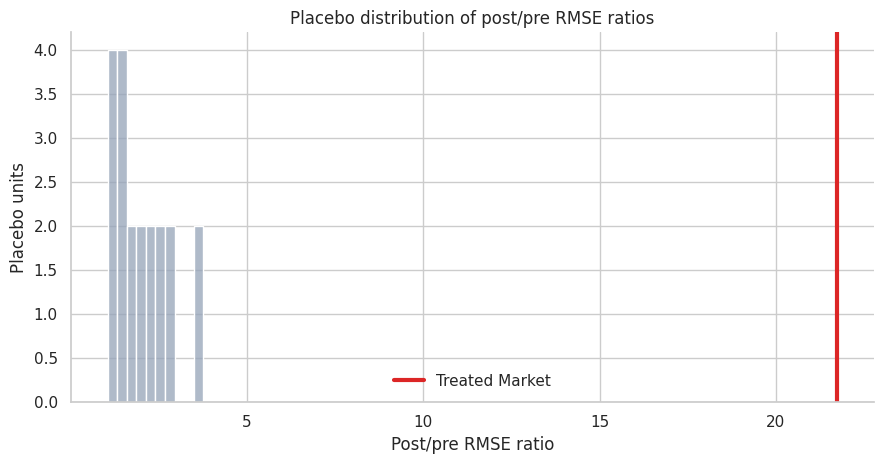

In [16]:
fig, ax = plt.subplots(figsize=(9, 4.8))
sns.histplot(placebo_table["post_to_pre_RMSE_ratio"], bins=10, color="#94a3b8", edgecolor="white", ax=ax)
ax.axvline(treated_ratio, color="#dc2626", linewidth=3, label="Treated Market")
ax.set_title("Placebo distribution of post/pre RMSE ratios")
ax.set_xlabel("Post/pre RMSE ratio")
ax.set_ylabel("Placebo units")
ax.legend(frameon=False)
sns.despine(ax=ax)
plt.tight_layout()


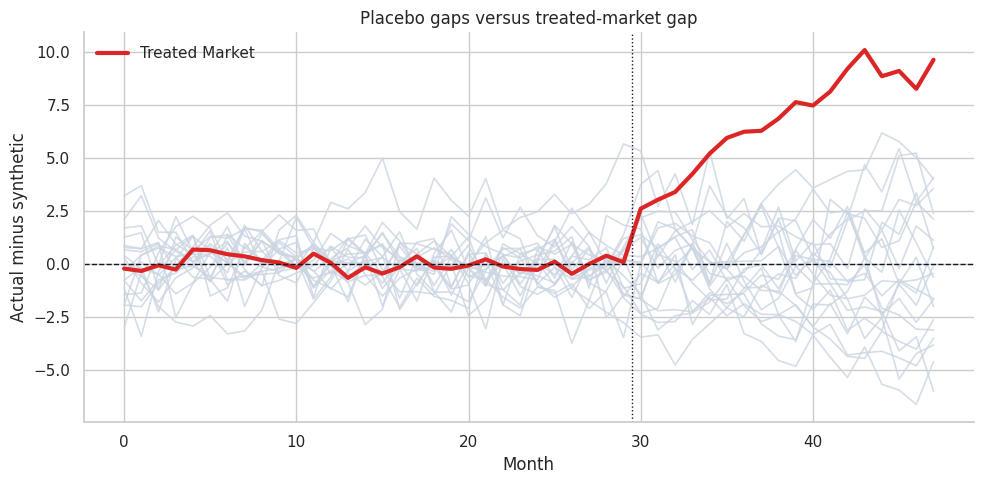

In [17]:
fig, ax = plt.subplots(figsize=(10, 5.0))
for placebo_unit, group in placebo_paths.groupby("placebo_unit", observed=True):
    ax.plot(group["month"], group["gap"], color="#cbd5e1", linewidth=1.2, alpha=0.8)
ax.plot(synth_path["month"], synth_path["gap"], color="#dc2626", linewidth=3, label="Treated Market")
ax.axhline(0, color="#111827", linestyle="--", linewidth=1)
ax.axvline(intervention_month - 0.5, color="#111827", linestyle=":", linewidth=1)
ax.set_title("Placebo gaps versus treated-market gap")
ax.set_xlabel("Month")
ax.set_ylabel("Actual minus synthetic")
ax.legend(frameon=False)
sns.despine(ax=ax)
plt.tight_layout()


The treated-market gap is much more unusual after launch than the donor placebo gaps. The randomization-style p-value is not a classical large-sample p-value; it is a design-based comparison against the donor pool. With only 20 donors, the smallest possible value is $1/(20+1)$.


## 8. Leave-One-Out Sensitivity

A synthetic control can depend heavily on one donor. Leave-one-out checks remove each important donor and refit the synthetic control. If the conclusion disappears when one donor is removed, the analysis is fragile.


In [18]:
active_donors = weight_table.loc[weight_table["weight"] > 0.03, "unit"].tolist()
loo_rows = []
loo_paths = []

for removed_donor in active_donors:
    restricted_pool = [unit for unit in donor_units if unit != removed_donor]
    _, loo_path, _ = fit_synthetic_control(
        df,
        treated_unit="Treated Market",
        donor_units=restricted_pool,
        intervention_month=intervention_month,
    )
    loo_path = loo_path.copy()
    loo_path["removed_donor"] = removed_donor
    loo_paths.append(loo_path)
    metrics = summarize_path(loo_path, intervention_month)
    loo_rows.append({"removed_donor": removed_donor, **metrics.to_dict()})

loo_table = pd.DataFrame(loo_rows).sort_values("average_post_gap")
loo_table


,removed_donor,pre_RMSE,post_RMSE,post_to_pre_RMSE_ratio,average_post_gap
3,Donor 18,0.412,6.485,15.740,6.172
1,Donor 14,0.456,6.738,14.786,6.394
2,Donor 07,0.412,6.702,16.256,6.408
5,Donor 10,0.332,7.160,21.543,6.785
4,Donor 02,0.348,7.282,20.923,6.886
0,Donor 03,0.463,7.568,16.355,7.199


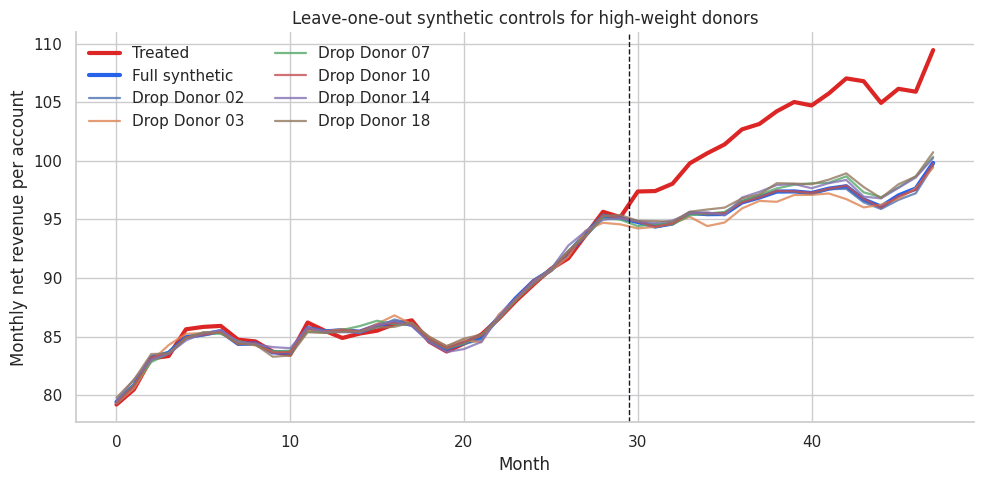

In [19]:
fig, ax = plt.subplots(figsize=(10, 5.0))
ax.plot(synth_path["month"], synth_path["treated"], color="#dc2626", linewidth=3, label="Treated")
ax.plot(synth_path["month"], synth_path["synthetic"], color="#2563eb", linewidth=3, label="Full synthetic")
for removed_donor, group in pd.concat(loo_paths).groupby("removed_donor", observed=True):
    ax.plot(group["month"], group["synthetic"], linewidth=1.6, alpha=0.8, label=f"Drop {removed_donor}")
ax.axvline(intervention_month - 0.5, color="#111827", linestyle="--", linewidth=1)
ax.set_title("Leave-one-out synthetic controls for high-weight donors")
ax.set_xlabel("Month")
ax.set_ylabel("Monthly net revenue per account")
ax.legend(frameon=False, ncol=2)
sns.despine(ax=ax)
plt.tight_layout()


The leave-one-out paths remain below the treated market after launch. That supports the conclusion that the result is not driven by a single donor. The pre-fit may worsen a bit when an important donor is removed, which is expected.


## 9. What Bad Pre-Fit Looks Like

Synthetic control is credible only if the donor pool can reproduce the treated unit before treatment. A poor pre-treatment fit means the synthetic unit is already a bad counterfactual before the intervention.

To see this, remove the donors that actually form the treated market's best pre-treatment match.


In [20]:
top_true_donors = true_weight_table.loc[true_weight_table["true_data_generating_weight"] > 0, "unit"].tolist()
restricted_donor_pool = [unit for unit in donor_units if unit not in top_true_donors]
restricted_weights, restricted_path, _ = fit_synthetic_control(
    df,
    treated_unit="Treated Market",
    donor_units=restricted_donor_pool,
    intervention_month=intervention_month,
)

restricted_summary = pd.DataFrame(
    {
        "Full donor pool": summarize_path(synth_path, intervention_month),
        "Restricted donor pool": summarize_path(restricted_path, intervention_month),
    }
).T
restricted_summary


,pre_RMSE,post_RMSE,post_to_pre_RMSE_ratio,average_post_gap
Full donor pool,0.329,7.156,21.748,6.786
Restricted donor pool,0.622,5.607,9.019,5.373


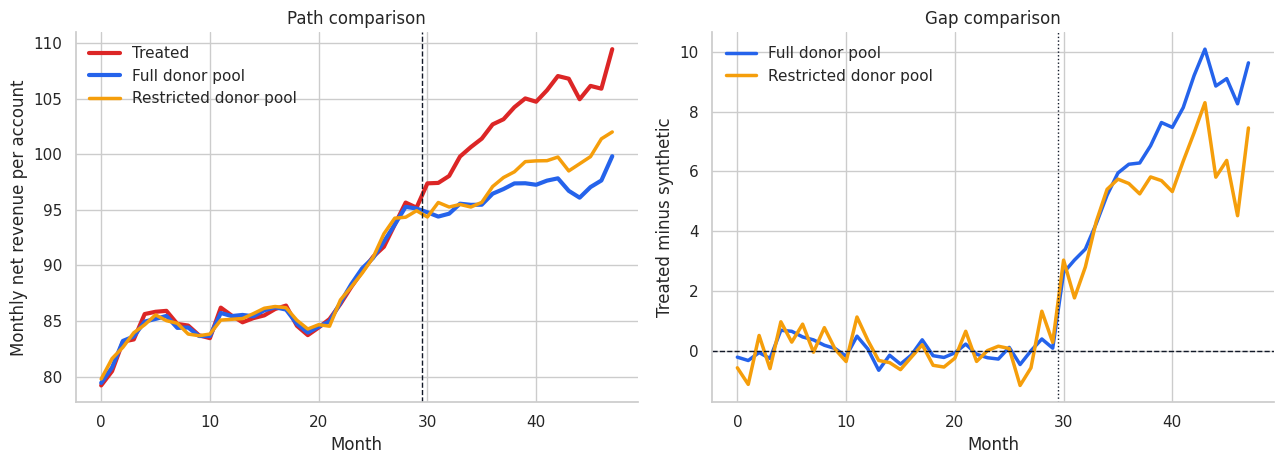

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=False)

axes[0].plot(synth_path["month"], synth_path["treated"], color="#dc2626", linewidth=3, label="Treated")
axes[0].plot(synth_path["month"], synth_path["synthetic"], color="#2563eb", linewidth=3, label="Full donor pool")
axes[0].plot(restricted_path["month"], restricted_path["synthetic"], color="#f59e0b", linewidth=2.5, label="Restricted donor pool")
axes[0].axvline(intervention_month - 0.5, color="#111827", linestyle="--", linewidth=1)
axes[0].set_title("Path comparison")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Monthly net revenue per account")
axes[0].legend(frameon=False)

axes[1].plot(synth_path["month"], synth_path["gap"], color="#2563eb", linewidth=2.5, label="Full donor pool")
axes[1].plot(restricted_path["month"], restricted_path["gap"], color="#f59e0b", linewidth=2.5, label="Restricted donor pool")
axes[1].axhline(0, color="#111827", linestyle="--", linewidth=1)
axes[1].axvline(intervention_month - 0.5, color="#111827", linestyle=":", linewidth=1)
axes[1].set_title("Gap comparison")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Treated minus synthetic")
axes[1].legend(frameon=False)

for ax in axes:
    sns.despine(ax=ax)
plt.tight_layout()


The restricted donor pool has worse pre-treatment fit. A post-treatment gap from this restricted design is less credible because the counterfactual was already missing the treated unit before launch. This is why pre-fit is not a cosmetic diagnostic; it is central to the design.


## 10. Augmented Synthetic Control: The Motivation

Sometimes the best convex donor combination still leaves meaningful pre-treatment imbalance. Augmented synthetic control uses an outcome model to estimate and correct bias from imperfect pre-treatment fit. Ben-Michael, Feller, and Rothstein (2021) describe this as a middle ground: keep the transparency of synthetic control but add model-based bias correction when exact balance is not feasible.

The design tradeoff is familiar:

- Constrained synthetic control is transparent and avoids extrapolation, but may fit poorly if the treated unit lies outside the donor convex hull.
- Model-assisted or augmented methods can reduce bias from imperfect fit, but rely more heavily on modeling assumptions.

In an industry report, this should be framed honestly: if the basic synthetic control fits well, use it as the main design. If it fits poorly, consider augmented methods, but do not hide the poor pre-fit.


## 11. Donor Pool Rules

The donor pool is part of the design, not a nuisance parameter. A good donor should be:

- Untreated during the analysis window.
- Exposed to similar macro shocks as the treated unit.
- Not affected by spillovers from the treated intervention.
- Measured consistently with the treated unit.
- Plausibly relevant for the treated unit's untreated path.

A bad donor pool can produce a precise-looking but meaningless synthetic control. Abadie (2021) emphasizes feasibility and data requirements: synthetic control needs enough pre-treatment information and a donor pool capable of approximating the treated unit.


In [22]:
donor_audit = pd.DataFrame(
    {
        "Rule": [
            "No treatment contamination",
            "No spillovers",
            "Comparable measurement",
            "Common shocks",
            "Adequate pre-period",
            "Good pre-fit",
        ],
        "Question to ask": [
            "Did any donor receive the policy or a close substitute?",
            "Could treated-market launch change donor outcomes?",
            "Are outcome definitions and data pipelines identical?",
            "Do donors face the same demand, seasonality, and macro conditions?",
            "Are there enough pre-intervention periods to evaluate fit?",
            "Does the synthetic unit track the treated unit before launch?",
        ],
    }
)
donor_audit


,Rule,Question to ask
0,No treatment contamination,Did any donor receive the policy or a close su...
1,No spillovers,Could treated-market launch change donor outco...
2,Comparable measurement,Are outcome definitions and data pipelines ide...
3,Common shocks,"Do donors face the same demand, seasonality, a..."
4,Adequate pre-period,Are there enough pre-intervention periods to e...
5,Good pre-fit,Does the synthetic unit track the treated unit...


## 12. Industry Readout Template

A synthetic-control readout should make the design visible:

- **Treated unit:** Which market, region, customer, or product line changed?
- **Intervention date:** When did the intervention start operationally?
- **Donor pool:** Which units were eligible and why?
- **Exclusions:** Which units were removed because of spillovers, contamination, or data problems?
- **Weights:** Which donors formed the synthetic control?
- **Pre-fit:** Path plot, gap plot, and pre-treatment RMSE.
- **Effect path:** Treated minus synthetic after the intervention.
- **Placebos:** How unusual is the treated gap relative to donor placebo gaps?
- **Sensitivity:** Leave-one-out checks for high-weight donors.
- **Decision:** What action follows from the effect size and uncertainty?


In [23]:
readout = pd.DataFrame(
    {
        "Item": [
            "Treated unit",
            "Intervention",
            "Main estimate",
            "Pre-fit",
            "Placebo evidence",
            "High-weight donors",
            "Sensitivity",
            "Decision implication",
        ],
        "Example entry": [
            "Treated Market",
            f"Premium AI-assisted support policy launched at month {intervention_month}",
            f"Average post-launch gap {fit_summary.loc['average_post_gap', 'synthetic_control']:.2f}",
            f"Pre-treatment RMSE {fit_summary.loc['pre_RMSE', 'synthetic_control']:.2f}",
            f"Post/pre RMSE ratio p-value {placebo_p_value:.3f}",
            ", ".join(plot_weights.sort_values("weight", ascending=False)["unit"].head(4).tolist()),
            "Leave-one-out estimates retain a positive post-launch gap",
            "Scale policy if operational audit rules out donor contamination and spillovers",
        ],
    }
)
readout


,Item,Example entry
0,Treated unit,Treated Market
1,Intervention,Premium AI-assisted support policy launched at...
2,Main estimate,Average post-launch gap 6.79
3,Pre-fit,Pre-treatment RMSE 0.33
4,Placebo evidence,Post/pre RMSE ratio p-value 0.048
5,High-weight donors,"Donor 03, Donor 14, Donor 07, Donor 18"
6,Sensitivity,Leave-one-out estimates retain a positive post...
7,Decision implication,Scale policy if operational audit rules out do...


## Key Takeaways

- Synthetic control constructs a counterfactual from a weighted average of untreated donor units.
- Weights are chosen using pre-treatment information, not post-treatment outcomes.
- The path plot and pre-treatment RMSE are central diagnostics.
- The gap plot is the estimated treatment-effect path.
- Placebo-in-space tests compare the treated gap with gaps obtained by pretending each donor was treated.
- Leave-one-out checks reveal whether the result depends on one high-weight donor.
- Poor pre-treatment fit weakens the design, even if the post-treatment gap looks large.
- Donor-pool construction is a substantive design choice and should be reported transparently.


## References

Abadie, A. (2021). Using synthetic controls: Feasibility, data requirements, and methodological aspects. *Journal of Economic Literature, 59*(2), 391-425. https://doi.org/10.1257/jel.20191450

Abadie, A., Diamond, A., & Hainmueller, J. (2010). Synthetic control methods for comparative case studies: Estimating the effect of California's tobacco control program. *Journal of the American Statistical Association, 105*(490), 493-505. https://doi.org/10.1198/jasa.2009.ap08746

Abadie, A., Diamond, A., & Hainmueller, J. (2011). Synth: An R package for synthetic control methods in comparative case studies. *Journal of Statistical Software, 42*(13), 1-17. https://doi.org/10.18637/jss.v042.i13

Abadie, A., & Gardeazabal, J. (2003). The economic costs of conflict: A case study of the Basque Country. *American Economic Review, 93*(1), 113-132. https://doi.org/10.1257/000282803321455188

Ben-Michael, E., Feller, A., & Rothstein, J. (2021). The augmented synthetic control method. *Journal of the American Statistical Association, 116*(536), 1789-1803. https://doi.org/10.1080/01621459.2021.1929245
